# 🌸**Iris Dataset Classification using Spark MLlib**🌸

##### ⚙️ Machine Learning Workflow
This notebook shows a full machine learning workflow using PySpark MLlib to classify Iris species.

<br>

##### 🤖 Implemented Algorithms
*  **Logistic Regression**
*  **Random Forest**
*  **Decision Tree**

# **1. Environment Setup and Imports**


In [159]:
!pip install pyspark

In [160]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.feature import VectorAssembler

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [161]:
# Create a SparkSession
spark = SparkSession.builder.appName("irisClassification").getOrCreate()
print("Spark version:" + spark.version)

Spark version:4.0.2


# **2. Load the Iris dataset**

###  Dataset Overview:
The Iris dataset was imported from an online source. It contains **150 observations** of iris flowers categorized by **4 features** and **3 target classes**.

---

##### 📐 Features (Predictors)
*  **Sepal Length** (cm)
*  **Sepal Width** (cm)
*  **Petal Length** (cm)
*  **Petal Width** (cm)

<br>

##### 🏷️ Target Classes (Species)
1. **Setosa**
2. **Versicolor**
3. **Virginica**

In [162]:
#Load the iris dataset from the raw GitHub URL
iris = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/iris-data.csv')

#Convert the iris dataset into Spark DataFrame
df = spark.createDataFrame(iris)
df.printSchema()

root
 |-- sepal length: double (nullable = true)
 |-- sepal width: double (nullable = true)
 |-- petal length: double (nullable = true)
 |-- petal width: double (nullable = true)
 |-- class: string (nullable = true)



In [163]:
# Display basic statistics
df.describe().show()

# Check class distribution
print("Class distribution:")
df.groupBy("class").count().show()

+-------+------------------+-------------------+------------------+------------------+--------------+
|summary|      sepal length|        sepal width|      petal length|       petal width|         class|
+-------+------------------+-------------------+------------------+------------------+--------------+
|  count|               150|                150|               150|               150|           150|
|   mean| 5.843333333333332| 3.0540000000000007| 3.758666666666668|1.1986666666666665|          NULL|
| stddev|0.8280661279778628|0.43359431136217386|1.7644204199522624|0.7631607417008414|          NULL|
|    min|               4.3|                2.0|               1.0|               0.1|   Iris-setosa|
|    max|               7.9|                4.4|               6.9|               2.5|Iris-virginica|
+-------+------------------+-------------------+------------------+------------------+--------------+

Class distribution:
+---------------+-----+
|          class|count|
+------------

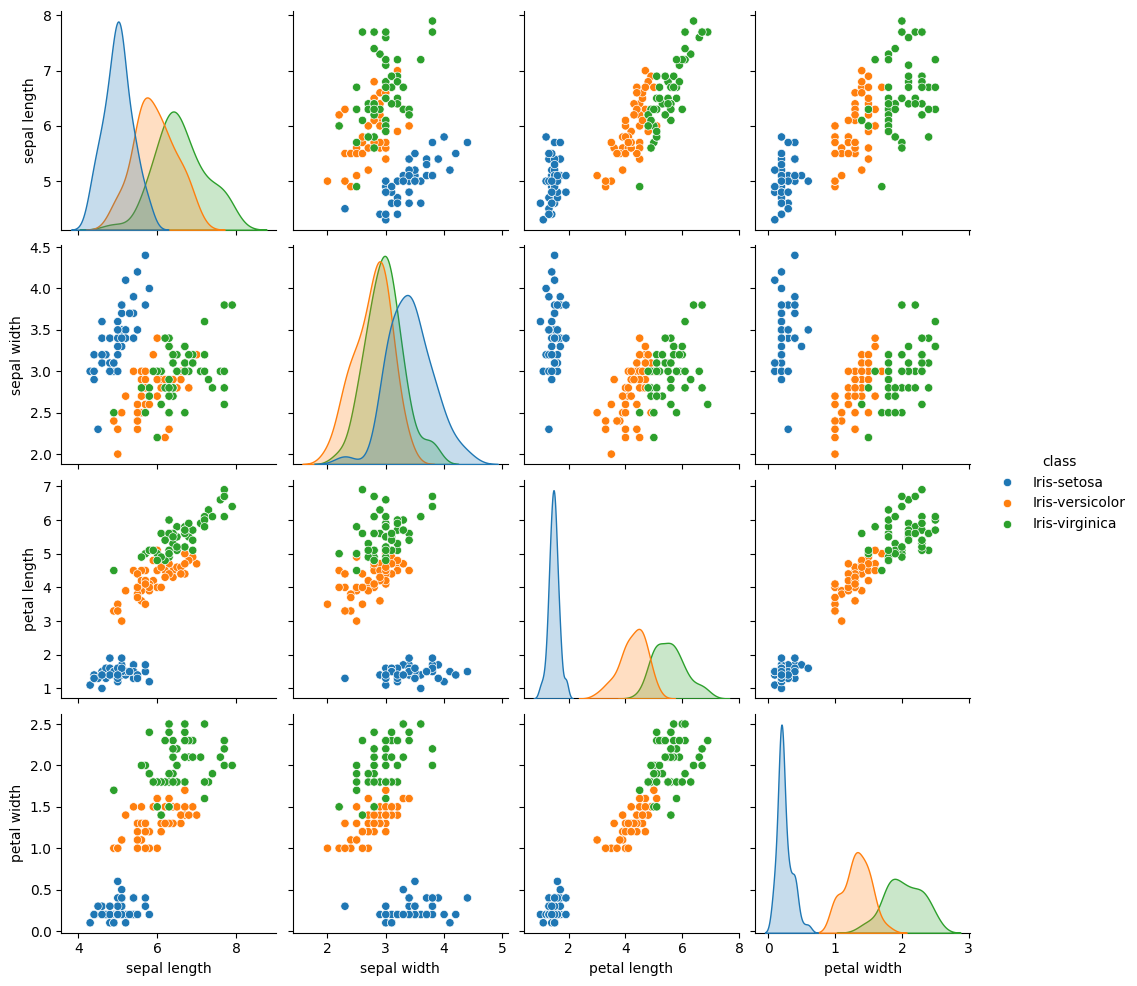

In [164]:
#Pair plot - relationship between features
sns.pairplot(iris, hue="class")
plt.show()

# **3. Data Preprocessing**

#####💡 **Vector Assembly**

PySpark MLlib requires all input features to be assembled into a single vector column before training can begin.

<br>

#####🏷️ **Label Encoding**

The string labels must be converted into numeric indices for the machine learning models to process them.



In [165]:
# Define feature columns
feature_columns = ['sepal length', 'sepal width', 'petal length', 'petal width']

# VectorAssembler: Combine feature columns into a single vector
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

In [166]:
# StringIndexer: Convert species names to numeric labels
label_indexer = StringIndexer(inputCol="class", outputCol="label")

In [167]:
# Apply transformations
df_indexed = label_indexer.fit(df).transform(df)
df_prepared = assembler.transform(df_indexed)

In [168]:
# Select only relevant columns
df_final = df_prepared.select("features", "label")

print('original data:')
df.show(5)
print("\ntransformed data:")
df_final.show(5)

original data:
+------------+-----------+------------+-----------+-----------+
|sepal length|sepal width|petal length|petal width|      class|
+------------+-----------+------------+-----------+-----------+
|         5.1|        3.5|         1.4|        0.2|Iris-setosa|
|         4.9|        3.0|         1.4|        0.2|Iris-setosa|
|         4.7|        3.2|         1.3|        0.2|Iris-setosa|
|         4.6|        3.1|         1.5|        0.2|Iris-setosa|
|         5.0|        3.6|         1.4|        0.2|Iris-setosa|
+------------+-----------+------------+-----------+-----------+
only showing top 5 rows

transformed data:
+-----------------+-----+
|         features|label|
+-----------------+-----+
|[5.1,3.5,1.4,0.2]|  0.0|
|[4.9,3.0,1.4,0.2]|  0.0|
|[4.7,3.2,1.3,0.2]|  0.0|
|[4.6,3.1,1.5,0.2]|  0.0|
|[5.0,3.6,1.4,0.2]|  0.0|
+-----------------+-----+
only showing top 5 rows


# **4. Train-Test Split**

The dataset is split into **80% training** and **20% testing** sets with a fixed seed to ensure reproducibility.

In [169]:
# Split the dataset
train, test = df_final.randomSplit([0.8, 0.2], seed=42)

print("Training Data:", train.count())
print("Testing Data:", test.count())

Training Data: 118
Testing Data: 32


In [170]:
#Verify train and test class distribution
print("Train data distribution:")
train.groupBy("label").count().show()

print("\nTest data distribution:")
test.groupBy("label").count().show()

Train data distribution:
+-----+-----+
|label|count|
+-----+-----+
|  0.0|   37|
|  1.0|   44|
|  2.0|   37|
+-----+-----+


Test data distribution:
+-----+-----+
|label|count|
+-----+-----+
|  0.0|   13|
|  1.0|    6|
|  2.0|   13|
+-----+-----+



# **5. Model Implementation with Hyperparameter Tuning**

🤖 Implemented Algorithms:

1.  **Logistic Regression**

    A robust linear model extended to multiclass classification due to its simplicity, computational efficiency and interpretability.It is widely used for multi-class classification problems.

2.  **Decision Tree**

    A simple and highly interpretable tree-based model. It can capture non-linear relationships between features and generates easily interpretable decision rules.

3.  **Random Forest**

    An ensemble of decision trees built to improved accuracy and reduce overfitting.


<br>

 ⚙️ Hyperparameter Tuning

Each model undergoes **5-fold cross-validation** paired with a **grid search** to ensure optimal hyperparameter selection and prevent overfitting.


In [171]:
# Create a standard multi-class evaluator for accuracy
evaluator = MulticlassClassificationEvaluator(labelCol="label",
                                              predictionCol="prediction",
                                              metricName="accuracy")

# Dictionary to store results
results = {}

### **Logistic Regression**

In [172]:
# Initialize Logistic Regression
lr = LogisticRegression(labelCol="label", featuresCol="features", family="multinomial")

# Define hyperparameter grid
lr_param_grid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.05, 0.1]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .addGrid(lr.maxIter, [10, 50])\
    .build()

print(f"Logistic Regression: Testing {len(lr_param_grid)} parameter combinations")

Logistic Regression: Testing 18 parameter combinations


In [173]:
# Cross-validator
lr_cv = CrossValidator(estimator=lr, estimatorParamMaps=lr_param_grid,
                       evaluator=evaluator, numFolds=5, seed=42)

# Train model with cross-validation
lr_cv_model = lr_cv.fit(train)
lr_best_model = lr_cv_model.bestModel

print(f"\nBest Logistic Regression Parameters:")
print(f"  - regParam: {lr_best_model.getRegParam()}")
print(f"  - elasticNetParam: {lr_best_model.getElasticNetParam()}")
print(f"  - maxIter: {lr_best_model.getMaxIter()}")


Best Logistic Regression Parameters:
  - regParam: 0.01
  - elasticNetParam: 0.0
  - maxIter: 10


In [174]:
# Store results
results["Logistic Regression"] = {
    "model": lr_best_model,
    "cv_model": lr_cv_model
}

### **Decision Tree**

In [175]:
# Initialize Decision Tree
dt = DecisionTreeClassifier(labelCol="label", featuresCol="features")

# Define hyperparameter grid
dt_param_grid = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [3, 5, 10]) \
    .addGrid(dt.impurity, ["gini", "entropy"]) \
    .addGrid(dt.minInstancesPerNode, [1, 2, 3])\
    .build()

print(f"Decision Tree: Testing {len(dt_param_grid)} parameter combinations")

Decision Tree: Testing 18 parameter combinations


In [176]:
# Cross-validator
dt_cv = CrossValidator(estimator=dt, estimatorParamMaps=dt_param_grid,
                       evaluator=evaluator, numFolds=5, seed=42)

# Train model with cross-validation
dt_cv_model = dt_cv.fit(train)
dt_best_model = dt_cv_model.bestModel

print(f"\nBest Decision Tree Parameters:")
print(f"  - maxDepth: {dt_best_model.getMaxDepth()}")
print(f"  - impurity: {dt_best_model.getImpurity()}")
print(f"  - minInstancesPerNode: {dt_best_model.getMinInstancesPerNode()}")


Best Decision Tree Parameters:
  - maxDepth: 5
  - impurity: entropy
  - minInstancesPerNode: 1


In [177]:
# Store results
results["Decision Tree"] = {
    "model": dt_best_model,
    "cv_model": dt_cv_model
}

### **Random Forest**

In [178]:
#Initialize Random Forest
rf = RandomForestClassifier(labelCol="label", featuresCol="features")

#Define hyperparameter grid
rf_param_grid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [20, 50,100]) \
    .addGrid(rf.maxDepth, [5,10,15]) \
    .addGrid(rf.maxBins, [16, 32]) \
    .build()

print(f"Random Forest: Testing {len(rf_param_grid)} parameter combinations")

Random Forest: Testing 18 parameter combinations


In [179]:
#Cross-validator
rf_cv = CrossValidator(estimator=rf, estimatorParamMaps=rf_param_grid,
                       evaluator=evaluator, numFolds=5, seed=42)

#Train model with cross-validation
rf_cv_model = rf_cv.fit(train)
rf_best_model = rf_cv_model.bestModel

print(f"\nBest Random Forest Parameters:")
print(f"  - numTrees: {rf_best_model.getNumTrees}")
print(f"  - maxDepth: {rf_best_model.getMaxDepth()}")
print(f"  - maxBins: {rf_best_model.getMaxBins()}")


Best Random Forest Parameters:
  - numTrees: 20
  - maxDepth: 10
  - maxBins: 32


In [180]:
# Store results
results["Random Forest"] = {
    "model": rf_best_model,
    "cv_model": rf_cv_model
}

# **6. Model Evaluation**

#### 📊 Each model is thoroughly evaluated using a variety of performance metrics:


*  **`Accuracy`** — Overall correctness of the predictions

*  **`Precision`** — Weighted precision across all classes

*  **`Recall/Sensitivity`** — Weighted recall across classes

*  **`F1-Score`** — Harmonic mean of precision and recall


In [181]:
#define function for model evaluation
def evaluate_model(model, test_data, model_name):
    """Evaluate a model and return metrics dictionary."""
    predictions = model.transform(test_data)

    metrics = {}
    for metric_name in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
        eval_metric = MulticlassClassificationEvaluator(
            labelCol="label",
            predictionCol="prediction",
            metricName=metric_name
        )
        metrics[metric_name] = eval_metric.evaluate(predictions)

    return predictions, metrics
# Evaluate all models
evaluation_results = {}
predictions_dict = {}
for model_name, model_data in results.items():
    predictions, metrics = evaluate_model(
        model_data["model"],
        test,
        model_name
    )
    evaluation_results[model_name] = metrics
    predictions_dict[model_name] = predictions

    print(f"\n{model_name} Performance:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['weightedPrecision']:.4f}")
    print(f"  Recall:    {metrics['weightedRecall']:.4f}")
    print(f"  F1-Score:  {metrics['f1']:.4f}")


Logistic Regression Performance:
  Accuracy:  0.9688
  Precision: 0.9732
  Recall:    0.9688
  F1-Score:  0.9693

Decision Tree Performance:
  Accuracy:  0.9062
  Precision: 0.9375
  Recall:    0.9062
  F1-Score:  0.9095

Random Forest Performance:
  Accuracy:  0.9688
  Precision: 0.9732
  Recall:    0.9688
  F1-Score:  0.9693


# **7. Predictions on Test Data**

In [182]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(evaluation_results).T
comparison_df.columns = ["Accuracy", "Precision", "Recall", "F1-Score"]
comparison_df = comparison_df.round(4)

print("Model Comparison Summary:")
print(comparison_df.to_string())

Model Comparison Summary:
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9688     0.9732  0.9688    0.9693
Decision Tree          0.9062     0.9375  0.9062    0.9095
Random Forest          0.9688     0.9732  0.9688    0.9693


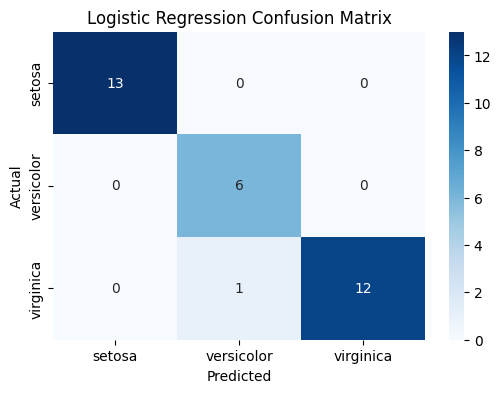

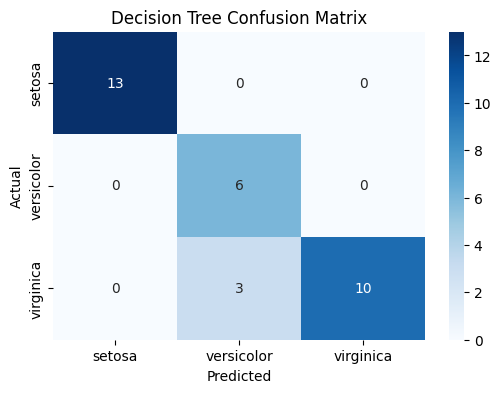

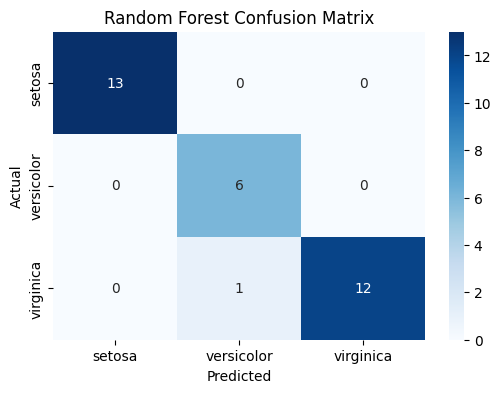

In [183]:
# Confusion Matrix
label_mapping = {
    0.0: "setosa",
    1.0: "versicolor",
    2.0: "virginica"
}

for model_name, predictions in predictions_dict.items():

    pred_pd = predictions.select(
        "label",
        "prediction"
    ).toPandas()

    pred_pd["label"] = pred_pd["label"].map(label_mapping)
    pred_pd["prediction"] = pred_pd["prediction"].map(label_mapping)

    cm = pd.crosstab(
        pred_pd["label"],
        pred_pd["prediction"]
    )

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

In [184]:
#Identify best model
best_model_name = comparison_df["Accuracy"].idxmax()
print(f"\nBest performing model: {best_model_name}")

# Retrieve the metrics for the best model
best_metrics = evaluation_results[best_model_name]


Best performing model: Logistic Regression


In [185]:
#Show predictions from best model
print(f"\nPerformance Metrics:")
print(f"  - Accuracy:  {best_metrics['accuracy']:.4f}")
print(f"  - Precision: {best_metrics['weightedPrecision']:.4f}")
print(f"  - Recall:    {best_metrics['weightedRecall']:.4f}")
print(f"  - F1-Score:  {best_metrics['f1']:.4f}")

print(f"\nSample Predictions ({best_model_name}):")
predictions_dict[best_model_name].select("features", "label", "prediction").show(10)


Performance Metrics:
  - Accuracy:  0.9688
  - Precision: 0.9732
  - Recall:    0.9688
  - F1-Score:  0.9693

Sample Predictions (Logistic Regression):
+-----------------+-----+----------+
|         features|label|prediction|
+-----------------+-----+----------+
|[4.4,3.0,1.3,0.2]|  0.0|       0.0|
|[4.6,3.2,1.4,0.2]|  0.0|       0.0|
|[4.6,3.6,1.0,0.2]|  0.0|       0.0|
|[4.8,3.1,1.6,0.2]|  0.0|       0.0|
|[4.9,3.1,1.5,0.1]|  0.0|       0.0|
|[5.0,3.2,1.2,0.2]|  0.0|       0.0|
|[5.0,3.6,1.4,0.2]|  0.0|       0.0|
|[5.1,3.8,1.5,0.3]|  0.0|       0.0|
|[5.4,3.7,1.5,0.2]|  0.0|       0.0|
|[5.4,3.9,1.3,0.4]|  0.0|       0.0|
+-----------------+-----+----------+
only showing top 10 rows


# **8. Comparative Analysis**

 ##### **Performance comparison using evaluation metrics:**


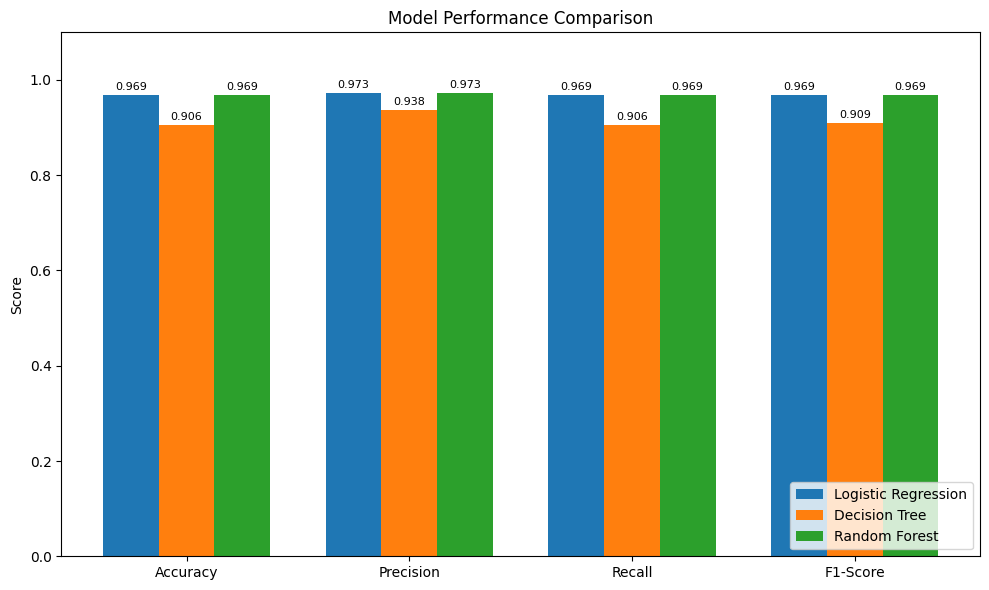

In [186]:
# Plot comparison - performance metrics

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(comparison_df.columns))
width = 0.25
multiplier = 0
for model_name, row in comparison_df.iterrows():
    offset = width * multiplier
    bars = ax.bar([i + offset for i in x], row.values, width, label=model_name)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)
    multiplier += 1
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks([i + width for i in x])
ax.set_xticklabels(comparison_df.columns)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [187]:
# Coefficients from the best Logistic Regression
print("The Coefficients for Logistic Regression Model:\n")

feature_columns = ['sepal length', 'sepal width', 'petal length', 'petal width']
coeff_matrix = lr_best_model.coefficientMatrix.toArray()

for class_idx, coeffs in enumerate(coeff_matrix):
    print(f"\nClass {class_idx} coefficients:")
    for feature, coef in zip(feature_columns, coeffs):
        print(f"  {feature}: {coef:.4f}")

The Coefficients for Logistic Regression Model:


Class 0 coefficients:
  sepal length: -1.2610
  sepal width: 2.2157
  petal length: -0.9899
  petal width: -2.1985

Class 1 coefficients:
  sepal length: 0.4830
  sepal width: -0.6548
  petal length: -0.1448
  petal width: -0.7909

Class 2 coefficients:
  sepal length: 0.7781
  sepal width: -1.5608
  petal length: 1.1347
  petal width: 2.9894


Feature Importance Analysis:

Decision Tree Feature Importance:
  sepal length: 0.0292
  sepal width: 0.0000
  petal length: 0.9708
  petal width: 0.0000

Random Forest Feature Importance:
  sepal length: 0.0995
  sepal width: 0.0093
  petal length: 0.4431
  petal width: 0.4481


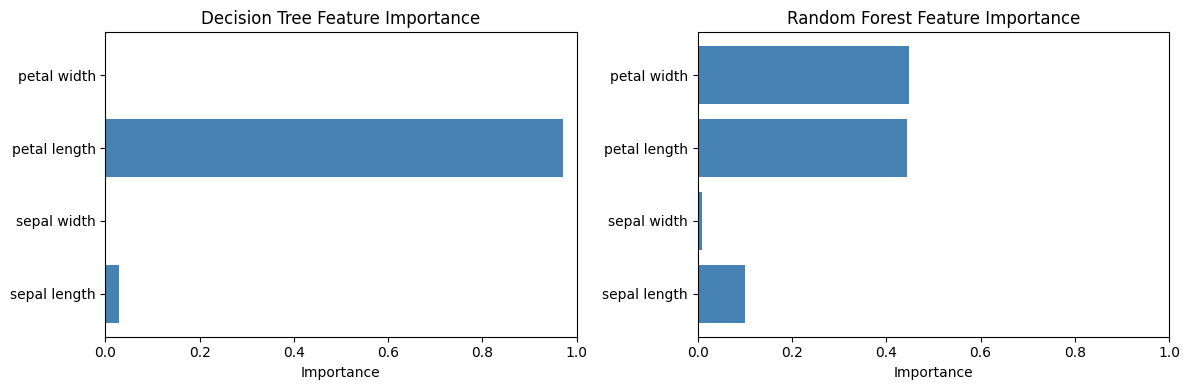

In [188]:
# Feature Importance Analysis - for tree-based models
print("Feature Importance Analysis:\n")

# Decision Tree
dt_importance = results["Decision Tree"]["model"].featureImportances.toArray()
print("Decision Tree Feature Importance:")
for name, importance in zip(feature_columns, dt_importance):
    print(f"  {name}: {importance:.4f}")
print()

# Random Forest
rf_importance = results["Random Forest"]["model"].featureImportances.toArray()
print("Random Forest Feature Importance:")
for name, importance in zip(feature_columns, rf_importance):
    print(f"  {name}: {importance:.4f}")

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (model_name, importances) in zip(
    axes,
    [("Decision Tree", dt_importance), ("Random Forest", rf_importance)]
):
    ax.barh(feature_columns, importances, color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title(f'{model_name} Feature Importance')
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

 ##### **Strengths and limitations of each model:**


###### 1. **Logistic Regression**

  `Strengths:`
* Logistic Regression achieved strong predictive performance on the Iris dataset.

* The model misclassified only one instance (Virginica predicted as Versicolor) which is consistent with the most challenging class boundary in the iris dataset.

* It delivered stable, balanced predictions across all classes and generalized well on the Iris dataset.

* This model is computationally efficient and easy to interpret, making it suitable for understanding how each feature contributes to class separation.

`Limitations:`
* Logistic Regression assumes linear decision boundaries between classes, which limit its flexibility in capturing more complex or non-linear patterns in the data.

* Although it performed well on this dataset, its effectiveness may decrease in datasets where class relationships are highly non-linear or more complex.

---
<br>

###### 2. **Decision Tree**

 `Strengths:`
* Decision Tree provides a simple and interpretable model with clear decision rules.

* It can capture non-linear relationships between features without requiring feature transformation.

* In this study, it successfully identified petal length as the influential feature which aligns perfectly with the pairplot visualisation.

 `Limitations:`
* The Decision Tree model performed worse than the other two models as it misclassifying three instances of Virginica as Versicolor.

* Feature importance analysis shows that the model heavily relied on a single feature (petal length with importance 0.9708) and ignoring other informative variables.

* This over-reliance likely contributed to reduced generalisation performance and higher variance compared to ensemble methods.

---
<br>

###### 3. **Random Forest**

 `Strengths:`
* Random Forest achieved the same classification performance as Logistic Regression. Only misclassifying only one instance (Virginica predicted as Versicolor).

* It demonstrated strong robustness by combining multiple decision trees, which succesfully reduces variance and improves generalisation.

* Feature importance analysis shows that it does not rely on a single feature, instead it distributes importance across both petal length and petal width. This is consistent with the pair plot visualization that shows that both petal features provide the clearest, most distinct separation between the three species.

* This balanced approach contributes to its stable performance and high resistance to overfitting.

 `Limitations:`
* Despite strong predictive performance, Random Forest is less interpretable than Logistic Regression and Decision Trees.

* The ensemble structure of multiple trees rather than a single decision rule makes it difficult to trace individual decision paths.

* It is also more computationally expensive, although this is not a significant limitation for small datasets like Iris.

 ##### **Justification of the best-performing model:**

In [189]:
print("=" * 60)
print("FINAL RECOMMENDATION")
print("=" * 60)

# Get metrics for best model
best_metrics = evaluation_results[best_model_name]
print(f"\nBest Model: {best_model_name}")
print(f"\nPerformance Metrics:")
print(f"  - Accuracy:  {best_metrics['accuracy']:.4f}")
print(f"  - Precision: {best_metrics['weightedPrecision']:.4f}")
print(f"  - Recall:    {best_metrics['weightedRecall']:.4f}")
print(f"  - F1-Score:  {best_metrics['f1']:.4f}")

#Justification
print("\nJustification:")
print("""
Logistic Regression was selected as the preferred model based on its strong predictive performance and model simplicity.

1. It achieved the highest observed performance across all evaluation metrics, including accuracy, precision, recall and F1-score.
2. It produced only one misclassification as Iris Virginica sample was incorrectly classified as Versicolor.
3. Its performance was identical to Random Forest while outperforming the Decision Tree model across all evaluation metrics.

Although Random Forest achieved the same predictive performance and produced the same single misclassification,
Logistic Regression was preferred because of its:

1. Simpler structure
2. Lower computational complexity
3. Greater interpretability

Logistic Regression provides explicit feature coefficients,
making it easier to interpret the influence of each feature on the predicted class compared to tree-based models.

Therefore, Logistic Regression is recommended as the most suitable model for this study, as it delivers excellent
classification performance while maintaining simplicity and interpretability.
""")

FINAL RECOMMENDATION

Best Model: Logistic Regression

Performance Metrics:
  - Accuracy:  0.9688
  - Precision: 0.9732
  - Recall:    0.9688
  - F1-Score:  0.9693

Justification:

Logistic Regression was selected as the preferred model based on its strong predictive performance and model simplicity.

1. It achieved the highest observed performance across all evaluation metrics, including accuracy, precision, recall and F1-score.
2. It produced only one misclassification as Iris Virginica sample was incorrectly classified as Versicolor.
3. Its performance was identical to Random Forest while outperforming the Decision Tree model across all evaluation metrics.

Although Random Forest achieved the same predictive performance and produced the same single misclassification, 
Logistic Regression was preferred because of its:

1. Simpler structure
2. Lower computational complexity
3. Greater interpretability

Logistic Regression provides explicit feature coefficients, 
making it easier to in

# **9. Cleanup**

In [190]:
# Stop Spark session
spark.stop()
print("Spark session stopped.")

Spark session stopped.
